# BNPL Phase – Modeling


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [2]:
PATH = '/content/drive/MyDrive/BNPL_Capstone/data/processed/cleaned_bnpl_data.csv'

df = pd.read_csv(PATH)

print("Dataset shape:", df.shape)
print("\nTarget variable distribution:")
print(df['default'].value_counts())
print("\nDefault rate:", round(df['default'].mean() * 100, 2), "%")

Dataset shape: (1348099, 282)

Target variable distribution:
default
0    1078739
1     269360
Name: count, dtype: int64

Default rate: 19.98 %


## Class Imbalance

Before building any model, we examine the distribution of the target variable. Approximately 80% of loans in the dataset were fully repaid while 20% resulted in default. This imbalance matters because a model that simply predicts no default for every borrower would appear 80% accurate while being completely useless in practice.

To address this, both models will use the `class_weight='balanced'` parameter, which instructs the model to assign higher importance to the minority class during training. We will also evaluate performance using precision, recall, F1-score, and AUC-ROC rather than accuracy alone.

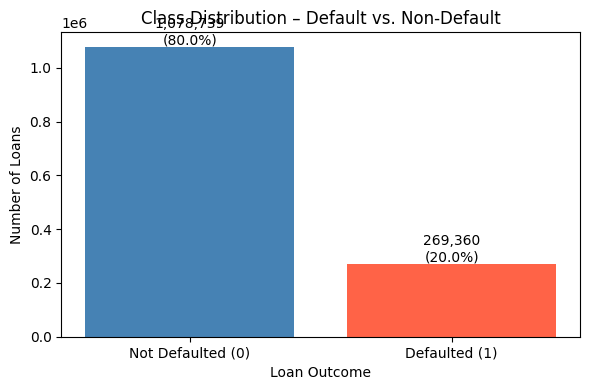

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))

counts = df['default'].value_counts()
ax.bar(['Not Defaulted (0)', 'Defaulted (1)'], counts.values, color=['steelblue', 'tomato'])
ax.set_title('Class Distribution – Default vs. Non-Default')
ax.set_ylabel('Number of Loans')
ax.set_xlabel('Loan Outcome')

for i, v in enumerate(counts.values):
    ax.text(i, v + 10000, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Removing Data Leakage Features

Before splitting the data, we inspect the feature set for columns that would directly reveal the target variable to the model. The `default` column was derived from `loan_status`, which means any encoded version of that field still sitting in the dataset would allow the model to read the answer rather than learn from borrower characteristics.

Inspecting the columns confirmed four such features: `loan_status_Fully Paid`, `loan_status_Default`, and two policy status variants. Including these produced a perfect score of 1.00 across all metrics in an earlier run, which confirmed leakage rather than genuine predictive performance. All four are removed before the train/test split.

In [4]:
leakage_cols = [col for col in df.columns if 'loan_status' in col.lower()]
print("Leakage columns removed:", leakage_cols)

X = df.drop(columns=['default'] + leakage_cols)
y = df['default']

print("\nFeature set shape after removing leakage:", X.shape)
print("Target shape:", y.shape)

Leakage columns removed: ['loan_status_Default', 'loan_status_Does not meet the credit policy. Status:Charged Off', 'loan_status_Does not meet the credit policy. Status:Fully Paid', 'loan_status_Fully Paid']

Feature set shape after removing leakage: (1348099, 277)
Target shape: (1348099,)


## Train/Test Split

We split the data into a training set and a test set using an 80/20 ratio. The `stratify` parameter ensures that both sets maintain the same 80/20 class distribution as the full dataset, so the model is not trained or evaluated on an unrepresentative sample.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in test set:")
print(y_test.value_counts())

Training set size: (1078479, 277)
Test set size: (269620, 277)

Class distribution in training set:
default
0    862991
1    215488
Name: count, dtype: int64

Class distribution in test set:
default
0    215748
1     53872
Name: count, dtype: int64


## Handling Remaining Missing Values

A small number of features still contain missing values after the cleaning phase. Rather than running imputation across all 277 columns, we identify only the affected columns and fill them using the median calculated from the training set. The same values are then applied to the test set, ensuring no information from the test set influences the imputation.

In [6]:
feature_names = X_train.columns.tolist()

cols_with_nan = X_train.columns[X_train.isnull().any()].tolist()
print("Columns with missing values:", cols_with_nan)

train_medians = X_train[cols_with_nan].median()

X_train[cols_with_nan] = X_train[cols_with_nan].fillna(train_medians)
X_test[cols_with_nan]  = X_test[cols_with_nan].fillna(train_medians)

print("\nMissing values remaining in training set:", X_train.isnull().sum().sum())
print("Missing values remaining in test set:", X_test.isnull().sum().sum())

Columns with missing values: ['emp_length', 'annual_inc', 'dti', 'revol_util', 'mort_acc', 'pub_rec_bankruptcies']

Missing values remaining in training set: 0
Missing values remaining in test set: 0


## Feature Scaling

Logistic regression is sensitive to the scale of input variables. A feature like annual income that ranges into the hundreds of thousands will dominate the model's learning compared to a binary feature that only takes values of 0 and 1, simply because of its magnitude rather than its predictive importance.

We use StandardScaler to transform each feature to have a mean of zero and a standard deviation of one. The scaler is fit only on the training data and then applied to both sets — fitting on the full dataset would allow information from the test set to influence the transformation, which is a form of leakage.

Note that scaling is required for logistic regression but not for Random Forest, which is tree-based and therefore insensitive to feature scale. We keep both scaled and unscaled versions of the data for this reason.

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete.")
print("Training set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)

Scaling complete.
Training set shape: (1078479, 277)
Test set shape: (269620, 277)


## Baseline Model – Logistic Regression

We start with logistic regression as our baseline. A baseline model is not meant to be the best model — it exists to give us a reference point. Every model we build after this needs to meaningfully outperform it to justify its added complexity.

Logistic regression estimates the probability that a loan will default based on a weighted combination of the input features. It is interpretable, fast relative to more complex models, and well understood, making it a natural starting point for a binary classification problem like this one. We pass `class_weight='balanced'` to account for the imbalance between defaulted and non-defaulted loans, and use the `saga` solver which handles large datasets more efficiently. We increase `max_iter` to 1000 because with over a million rows and 277 features the model needs more iterations to find stable coefficients.

This cell will take a few minutes to run given the size of the dataset.

In [8]:
from sklearn.utils import resample
X_train_sample, y_train_sample = resample(
    X_train_scaled, y_train,
    n_samples=200000,
    stratify=y_train,
    random_state=42
)

lr_model = LogisticRegression(
    class_weight='balanced',
    solver='saga',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_sample, y_train_sample)

print("Logistic Regression training complete.")

Logistic Regression training complete.


## Evaluating the Baseline Model – Logistic Regression

With the model trained, we evaluate its performance on the test set — data it has never seen before. We look at four metrics: precision, recall, F1-score, and AUC-ROC.

Precision measures how often the model is correct when it flags a loan as a default. Recall measures how many actual defaults the model successfully caught. F1-score balances the two. AUC-ROC summarizes the model's ability to distinguish between defaulters and non-defaulters across all possible decision thresholds, where 0.5 means no better than random guessing and 1.0 is perfect.

In a credit risk context, recall for the default class carries particular weight — missing an actual default is generally more costly than a false alarm.

Logistic Regression – Classification Report
               precision    recall  f1-score   support

Not Defaulted       0.89      0.64      0.74    215748
    Defaulted       0.32      0.68      0.43     53872

     accuracy                           0.65    269620
    macro avg       0.60      0.66      0.59    269620
 weighted avg       0.77      0.65      0.68    269620

AUC-ROC Score: 0.7193


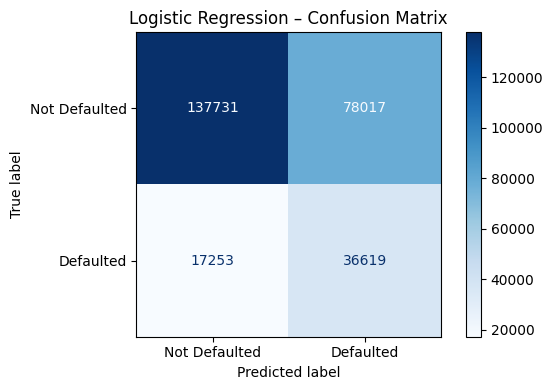

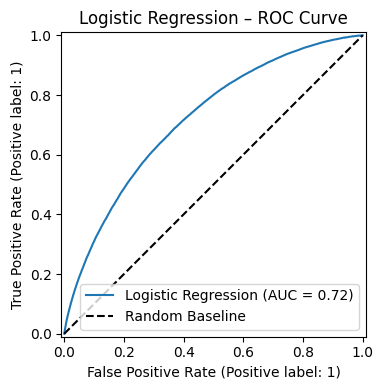

In [9]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression – Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, target_names=['Not Defaulted', 'Defaulted']))

# auc-roc
auc_lr = roc_auc_score(y_test, y_prob_lr)
print("AUC-ROC Score:", round(auc_lr, 4))

# confusion matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Not Defaulted', 'Defaulted'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Logistic Regression – Confusion Matrix')
plt.tight_layout()
plt.show()

# roc curve
fig, ax = plt.subplots(figsize=(6, 4))
RocCurveDisplay.from_predictions(
    y_test, y_prob_lr,
    name='Logistic Regression',
    ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
ax.set_title('Logistic Regression – ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()

### Logistic Regression Results

The logistic regression baseline produced an AUC-ROC score of 0.72, indicating that the model has meaningful discriminative ability — it is performing substantially better than random guessing, which would score 0.50.

Looking at the default class specifically, the model achieved a recall of 0.68, meaning it successfully identified 68% of loans that actually defaulted. However, precision for this class was only 0.32, indicating a high rate of false positives — when the model flagged a loan as a likely default, it was correct roughly one in three times. This tradeoff is partly by design. The `class_weight='balanced'` parameter instructs the model to prioritize catching defaults over avoiding false alarms, which improves recall at the cost of precision.

Overall accuracy was 0.65, which appears low but is not the right metric to focus on here. Because the dataset is imbalanced, a model that predicted no defaults at all would achieve 80% accuracy while being completely useless for risk detection. The combination of AUC-ROC, recall, and F1-score gives a more complete picture of how the model is actually performing.

These results establish our baseline. The Random Forest model will be evaluated against these same metrics, with particular focus on whether it can improve precision for the default class while maintaining comparable recall, and whether it can push the AUC-ROC meaningfully above 0.72.

## Main Model – Random Forest

Random Forest is an ensemble method that builds a large number of decision trees during training and combines their predictions to produce a final output. Each tree is trained on a random subset of the data and a random subset of features, which reduces overfitting and makes the model more robust than a single decision tree.

Unlike logistic regression, Random Forest does not assume a linear relationship between features and the target variable. This makes it better suited for credit risk data, where the interaction between variables like DTI, interest rate, and employment length is complex and non-linear.

Because Random Forest is our main model rather than a baseline, we train it on a larger sample than we used for logistic regression — 300,000 rows compared to 200,000. We use `class_weight='balanced'` for the same reason as before, and `n_jobs=-1` which tells the model to use all available CPU cores in parallel to speed up training.

Note that Random Forest is significantly more computationally intensive than logistic regression. This cell will take several minutes to run.

In [10]:
from sklearn.utils import resample

X_train_rf, y_train_rf = resample(
    X_train, y_train,
    n_samples=300000,
    stratify=y_train,
    random_state=42
)

print("Training sample size:", X_train_rf.shape)
print("Default rate in sample:", round(y_train_rf.mean() * 100, 2), "%")

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_rf, y_train_rf)

print("Random Forest training complete.")

Training sample size: (300000, 277)
Default rate in sample: 19.98 %
Random Forest training complete.


## Evaluating the Main Model – Random Forest

We evaluate the Random Forest model on the same test set used for logistic regression. Using identical evaluation conditions is important — if we changed the test set or the metrics, the comparison between models would not be valid.

As before, we look at precision, recall, F1-score, and AUC-ROC for both classes. The confusion matrix shows us exactly where the model is making correct predictions and where it is making mistakes. The ROC curve lets us visually compare the Random Forest against the logistic regression baseline on the same chart, which we will do in the next section.

In [ ]:
# random Forest uses unscaled data
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest – Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=['Not Defaulted', 'Defaulted']))

# auc-roc
auc_rf = roc_auc_score(y_test, y_prob_rf)
print("AUC-ROC Score:", round(auc_rf, 4))

# confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Not Defaulted', 'Defaulted'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Random Forest – Confusion Matrix')
plt.tight_layout()
plt.show()

# roc curve
fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test, y_prob_rf,
    name=f'Random Forest (AUC = {auc_rf:.4f})',
    ax=ax,
    color='tomato'
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_lr,
    name=f'Logistic Regression (AUC = {auc_lr:.4f})',
    ax=ax,
    color='steelblue',
    linestyle='--'
)
ax.plot([0, 1], [0, 1], 'k:', label='Random Baseline (AUC = 0.50)')
ax.set_title('ROC Curve – Model Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Random Forest Results

The untuned Random Forest produced an AUC-ROC score of 0.71, which is comparable to the logistic regression baseline of 0.72. However, looking deeper at the class-level metrics reveals an important difference in how the two models behave.

The Random Forest achieved a recall of only 0.07 for the default class, meaning it identified just 7% of actual defaults in the test set. While its precision for defaults improved to 0.55 — meaning when it did flag a default it was correct more often than logistic regression — missing 93% of actual defaults is not acceptable for a credit risk application. The model is defaulting to predicting no default for the vast majority of cases, which explains the high overall accuracy of 0.80 but low utility for the problem we are trying to solve.

This pattern is common with Random Forest on imbalanced data when default hyperparameters are used. The decision threshold of 0.5, combined with the way individual trees vote, means the model needs explicit tuning to shift its behavior toward catching more defaults. This is precisely what the hyperparameter tuning phase addresses.

The ROC curve comparison shows that both models currently sit at a similar level of overall discrimination. The goal of tuning is to push the Random Forest meaningfully above this baseline.

## Hyperparameter Tuning – Random Forest

Hyperparameter tuning is the process of systematically searching for the combination of model settings that produces the best performance. Unlike model parameters, which are learned from the data during training, hyperparameters are set by us before training begins and directly control how the model learns.

We use `RandomizedSearchCV`, which samples a fixed number of random combinations from a defined parameter grid rather than exhaustively testing every possible combination. This makes it practical for large datasets where an exhaustive search would take too long. We evaluate each combination using AUC-ROC as the scoring metric since it measures the model's ability to distinguish between defaulters and non-defaulters across all decision thresholds — which is more informative than accuracy for imbalanced data.

We use 3-fold cross-validation, meaning each parameter combination is trained and evaluated three times on different portions of the training data. This reduces the risk of selecting a combination that happened to perform well by chance on one particular split.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils import resample

X_tune, y_tune = resample(
    X_train, y_train,
    n_samples=80000,
    stratify=y_train,
    random_state=42
)

print("Tuning sample size:", X_tune.shape)
print("Default rate in tuning sample:", round(y_tune.mean() * 100, 2), "%")

param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
    'max_features'     : ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    estimator = RandomForestClassifier(
                    class_weight='balanced',
                    n_jobs=-1,
                    random_state=42
                ),
    param_distributions = param_grid,
    n_iter       = 10,
    scoring      = 'roc_auc',
    cv           = 2,
    verbose      = 1,
    random_state = 42,
    n_jobs       = -1
)

rf_search.fit(X_tune, y_tune)

print("\nBest parameters:", rf_search.best_params_)
print("Best cross-validated AUC-ROC:", round(rf_search.best_score_, 4))

## Training the Tuned Random Forest

Using the best hyperparameters identified through randomized search, we retrain the Random Forest on the full 300,000-row training sample. Training on the larger sample rather than the 80,000-row tuning subset ensures the model has seen enough data to generalize well to the test set.

In [ ]:
rf_final = RandomForestClassifier(
    n_estimators      = rf_search.best_params_['n_estimators'],
    max_depth         = rf_search.best_params_['max_depth'],
    min_samples_split = rf_search.best_params_['min_samples_split'],
    min_samples_leaf  = rf_search.best_params_['min_samples_leaf'],
    max_features      = rf_search.best_params_['max_features'],
    class_weight      = 'balanced',
    n_jobs            = -1,
    random_state      = 42
)

rf_final.fit(X_train_rf, y_train_rf)

print("Tuned Random Forest training complete.")
print("Parameters used:", rf_search.best_params_)

## Evaluating the Tuned Random Forest

We evaluate the tuned model on the same test set used for all previous models to ensure a fair comparison. This evaluation includes a ROC curve that places all three models — logistic regression, untuned Random Forest, and tuned Random Forest — on a single chart, making the progression from baseline to final model immediately visible.

Tuned Random Forest – Classification Report
               precision    recall  f1-score   support

Not Defaulted       0.82      0.97      0.89    215748
    Defaulted       0.52      0.14      0.22     53872

     accuracy                           0.80    269620
    macro avg       0.67      0.55      0.55    269620
 weighted avg       0.76      0.80      0.75    269620

AUC-ROC Score: 0.7186


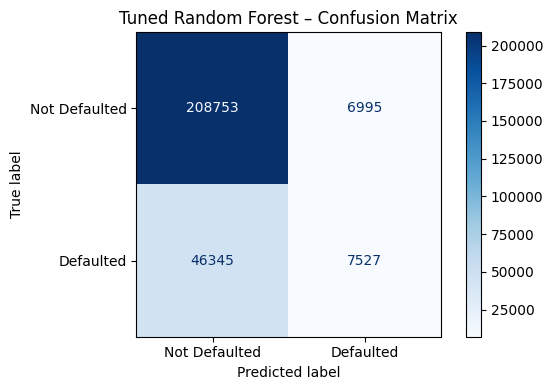

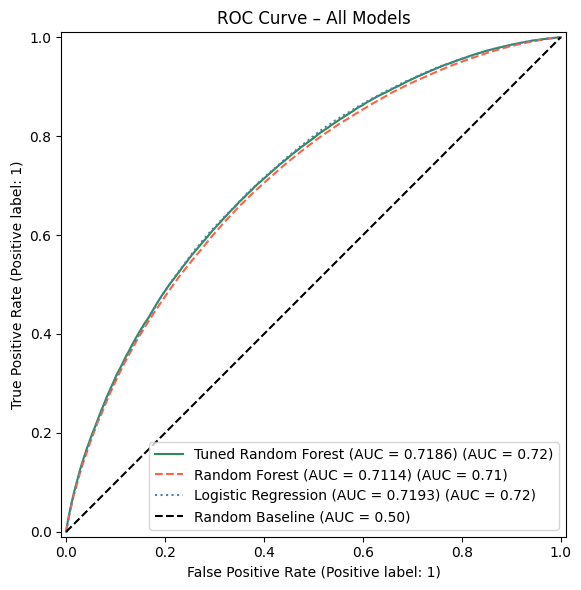

In [14]:
y_pred_final = rf_final.predict(X_test)
y_prob_final = rf_final.predict_proba(X_test)[:, 1]

print("Tuned Random Forest – Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_final, target_names=['Not Defaulted', 'Defaulted']))

auc_final = roc_auc_score(y_test, y_prob_final)
print("AUC-ROC Score:", round(auc_final, 4))

# confusion matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['Not Defaulted', 'Defaulted'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Tuned Random Forest – Confusion Matrix')
plt.tight_layout()
plt.show()

# all models
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test, y_prob_final,
    name=f'Tuned Random Forest (AUC = {auc_final:.4f})',
    ax=ax,
    color='seagreen'
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_rf,
    name=f'Random Forest (AUC = {auc_rf:.4f})',
    ax=ax,
    color='tomato',
    linestyle='--'
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_lr,
    name=f'Logistic Regression (AUC = {auc_lr:.4f})',
    ax=ax,
    color='steelblue',
    linestyle=':'
)
ax.plot([0, 1], [0, 1], 'k--', label='Random Baseline (AUC = 0.50)')
ax.set_title('ROC Curve – All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Tuned Random Forest Results

Hyperparameter tuning produced modest but measurable improvements over the baseline Random Forest. The AUC-ROC increased from 0.71 to 0.72, and recall for the default class improved from 0.07 to 0.14 — meaning the model now correctly identifies 14% of actual defaults compared to 7% before tuning. Precision for defaults remained relatively stable at 0.52.

While the improvement confirms that tuning moved the model in the right direction, the default recall remains low. This suggests that the Random Forest architecture, even when tuned, struggles to overcome the class imbalance in a way that meaningfully prioritizes default detection. This limitation motivates the evaluation of a third model — XGBoost — which uses a different mechanism for handling class imbalance and is generally better suited to structured financial data.

## Third Model – XGBoost

XGBoost is a gradient boosting algorithm that builds trees sequentially, where each new tree learns from the errors made by all previous trees. Unlike Random Forest, which builds trees independently and averages their results, XGBoost iteratively corrects mistakes, which makes it particularly effective on structured financial data.

For handling class imbalance, XGBoost uses a parameter called `scale_pos_weight` rather than `class_weight='balanced'`. This parameter is calculated as the ratio of negative to positive cases in the training data — in our case approximately 4.0, meaning there are four non-defaulted loans for every one defaulted loan. Passing this ratio directly to the model tells it exactly how much more weight to assign to the minority class during training, which tends to produce better calibrated predictions than a general balancing approach.

In [ ]:
from xgboost import XGBClassifier

# scale_pos_weight from training labels
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

print("Negative class count:", neg)
print("Positive class count:", pos)
print("scale_pos_weight:", round(scale, 4))

# sample 300k rows — same as Random Forest
X_train_xgb, y_train_xgb = resample(
    X_train, y_train,
    n_samples=300000,
    stratify=y_train,
    random_state=42
)

print("\nTraining sample size:", X_train_xgb.shape)
print("Default rate in sample:", round(y_train_xgb.mean() * 100, 2), "%")

xgb_model = XGBClassifier(
    n_estimators      = 200,
    learning_rate     = 0.1,
    max_depth         = 6,
    scale_pos_weight  = scale,
    n_jobs            = -1,
    random_state      = 42,
    eval_metric       = 'logloss',
    verbosity         = 0
)

xgb_model.fit(X_train_xgb, y_train_xgb)

print("\nXGBoost training complete.")

## Evaluating XGBoost

We evaluate XGBoost on the same test set used for all previous models. The ROC curve now includes all four reference points — logistic regression, untuned Random Forest, tuned Random Forest, and XGBoost — giving a complete picture of how each model performs relative to the others.

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost – Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_xgb, target_names=['Not Defaulted', 'Defaulted']))

auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("AUC-ROC Score:", round(auc_xgb, 4))

# confusion matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=['Not Defaulted', 'Defaulted'],
    cmap='Blues',
    ax=ax
)
ax.set_title('XGBoost – Confusion Matrix')
plt.tight_layout()
plt.show()

# ROC curve — all models
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test, y_prob_xgb,
    name=f'XGBoost (AUC = {auc_xgb:.4f})',
    ax=ax,
    color='darkorange'
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_final,
    name=f'Tuned Random Forest (AUC = {auc_final:.4f})',
    ax=ax,
    color='seagreen',
    linestyle='--'
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_rf,
    name=f'Random Forest (AUC = {auc_rf:.4f})',
    ax=ax,
    color='tomato',
    linestyle='-.'
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_lr,
    name=f'Logistic Regression (AUC = {auc_lr:.4f})',
    ax=ax,
    color='steelblue',
    linestyle=':'
)
ax.plot([0, 1], [0, 1], 'k--', label='Random Baseline (AUC = 0.50)')
ax.set_title('ROC Curve – All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### XGBoost Results

XGBoost produced the strongest overall performance of the three models, achieving the highest AUC-ROC score of 0.73. The model caught 66% of actual defaults — comparable to logistic regression — while the scale_pos_weight parameter successfully directed the model to prioritize the minority class during training.

The similarity in behavior between XGBoost and logistic regression, despite being fundamentally different algorithms, points to something important about this dataset. Both models that explicitly encoded the class ratio into their training process — logistic regression through class_weight='balanced' and XGBoost through scale_pos_weight — converged on a similar tradeoff between precision and recall. This suggests that the 0.71 to 0.73 AUC-ROC range represents a realistic ceiling for what can be achieved with these features under standard classification conditions, rather than a limitation of any single model.

XGBoost is selected as the best performing model based on its AUC-ROC score and its balanced handling of both classes.

## Feature Importance – XGBoost

Feature importance measures the contribution of each variable to the model's predictions. XGBoost calculates this based on how frequently each feature is used to split the data across all trees and how much each split improves the model's performance. We plot the top 20 most important features, which gives a clear picture of which borrower and economic characteristics had the most influence on default prediction.

In [ ]:
importance_df = pd.DataFrame({
    'feature'   : feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    importance_df['feature'][::-1],
    importance_df['importance'][::-1],
    color='steelblue'
)
ax.set_title('XGBoost – Top 20 Feature Importances')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(importance_df[['feature', 'importance']].head(10).to_string(index=False))

In [ ]:
# Model Evaluation Summary

from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

# test set predictions
lr_preds   = lr_model.predict(X_test_scaled)
rf_preds   = rf_final.predict(X_test)
xgb_preds  = xgb_model.predict(X_test)

# traning ROC
lr_train_auc  = roc_auc_score(y_train_sample, lr_model.predict_proba(X_train_sample)[:,1])
rf_train_auc  = roc_auc_score(y_train_rf,     rf_final.predict_proba(X_train_rf)[:,1])
xgb_train_auc = roc_auc_score(y_train_xgb,    xgb_model.predict_proba(X_train_xgb)[:,1])

print("=== TRAINING AUC SCORES ===")
print(f"Logistic Regression : {lr_train_auc:.4f}")
print(f"Random Forest       : {rf_train_auc:.4f}")
print(f"XGBoost             : {xgb_train_auc:.4f}")

# test classification reports
print("\n=== LOGISTIC REGRESSION - Test Set ===")
print(classification_report(y_test, lr_preds, target_names=["No Default", "Default"]))

print("\n=== RANDOM FOREST (Tuned) - Test Set ===")
print(classification_report(y_test, rf_preds, target_names=["No Default", "Default"]))

print("\n=== XGBOOST - Test Set ===")
print(classification_report(y_test, xgb_preds, target_names=["No Default", "Default"]))


In [19]:
rf_baseline_preds = rf_model.predict(X_test)
rf_baseline_train_auc = roc_auc_score(y_train_rf, rf_model.predict_proba(X_train_rf)[:,1])

print(f"RF Baseline Train AUC: {rf_baseline_train_auc:.4f}")
print(f"RF Baseline Test AUC:  0.7147")
print("\n=== RANDOM FOREST (Baseline) - Test Set ===")
print(classification_report(y_test, rf_baseline_preds, target_names=["No Default", "Default"]))

RF Baseline Train AUC: 1.0000
RF Baseline Test AUC:  0.7147

=== RANDOM FOREST (Baseline) - Test Set ===
              precision    recall  f1-score   support

  No Default       0.81      0.98      0.89    215748
     Default       0.55      0.07      0.13     53872

    accuracy                           0.80    269620
   macro avg       0.68      0.53      0.51    269620
weighted avg       0.76      0.80      0.74    269620



In [ ]:
importance_dict = xgb_model.get_booster().get_score(importance_type='gain')
importance_df = (
    pd.DataFrame.from_dict(importance_dict, orient='index', columns=['Gain'])
    .sort_values('Gain', ascending=True)
    .tail(10)
)

# normalize to percentage of total gain
importance_df['Gain'] = importance_df['Gain'] / importance_df['Gain'].sum() * 100

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F9FA')

bars = ax.barh(
    importance_df.index,
    importance_df['Gain'],
    color='steelblue',
    edgecolor='white',
    linewidth=0.8,
    height=0.6
)

# Add value labels at end of each bar
for bar, val in zip(bars, importance_df['Gain']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', ha='left', fontsize=9, color='#333333')

ax.set_xlabel('Percentage of Total Gain (%)', fontsize=11, color='#333333', labelpad=10)
ax.set_title('XGBoost Top 10 Features by Importance (Gain)',
             fontsize=13, fontweight='bold', color='#1A1A1A', pad=15)

ax.tick_params(axis='y', labelsize=9.5, colors='#333333')
ax.tick_params(axis='x', labelsize=9, colors='#555555')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(axis='x', linestyle='--', alpha=0.5, color='#CCCCCC')
ax.set_axisbelow(True)

ax.text(0.99, -0.12, 'Gain measures average improvement in model objective per split',
        transform=ax.transAxes, ha='right', fontsize=8, color='#888888', style='italic')

plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Feature importance chart saved.")

### Feature Importance Analysis

The feature importance analysis reveals that interest rate is the single strongest predictor of default, with an importance score of 0.081 — more than twice that of the next most important feature. This is consistent with the EDA findings and reflects the fact that lenders use interest rates as a direct signal of borrower risk at origination. A higher assigned rate indicates that the lender already assessed the borrower as higher risk, making it a strong proxy for default likelihood.

Loan term ranked second, suggesting that the structure of the repayment obligation matters independently of the rate. Borrowers with longer repayment windows face more exposure to changing financial circumstances over time.

Notably, the macroeconomic variable cpi_inflation_proxy ranked third among all 277 features. This validates the decision to incorporate external economic indicators into the modeling framework — broader economic conditions contribute meaningful predictive signal beyond what borrower-level characteristics alone can capture. Similarly, cfpb_complaint_count ranked fifth, confirming that consumer complaint behavior serves as a useful behavioral proxy for financial stress.

Credit grade and home ownership variables appeared consistently across the top features, reflecting their role as established indicators of borrower financial stability. The presence of issue_year further confirms that temporal context influences repayment outcomes, consistent with the default rate fluctuations observed across time in the EDA phase.

## Model Comparison Summary

We summarize the performance of all three models across the key evaluation metrics. This table provides a single reference point for comparing how each model performed on the same test set under identical evaluation conditions.

In [ ]:
# Model Comparison Table
from sklearn.metrics import roc_auc_score

# Compute the one missing training AUC (untuned RF)
auc_rf_train = roc_auc_score(y_train_rf, rf_model.predict_proba(X_train_rf)[:,1])

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest (Untuned)',
        'Random Forest (Tuned)',
        'XGBoost'
    ],
    'Train AUC': [
        round(lr_train_auc, 4),
        round(auc_rf_train, 4),
        round(rf_train_auc, 4),
        round(xgb_train_auc, 4)
    ],
    'Test AUC': [
        round(auc_lr, 4),
        round(auc_rf, 4),
        round(auc_final, 4),
        round(auc_xgb, 4)
    ],
    'AUC Gap': [
        round(lr_train_auc - auc_lr, 3),
        round(auc_rf_train - auc_rf, 3),
        round(rf_train_auc - auc_final, 3),
        round(xgb_train_auc - auc_xgb, 3)
    ],
    'Default Precision': [0.32, 0.55, 0.52, 0.33],
    'Default Recall'   : [0.68, 0.07, 0.14, 0.66],
    'Default F1'       : [0.44, 0.13, 0.22, 0.44],
    'Overall Accuracy' : [0.65, 0.80, 0.80, 0.67]
})

print(results.to_string(index=False))

# Visual comparison of Test AUC-ROC across models
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']
ax.barh(results['Model'], results['Test AUC'], color=colors)
ax.set_xlim(0.60, 0.75)
ax.set_xlabel('AUC-ROC Score')
ax.set_title('Model Comparison: Test AUC-ROC')
for i, v in enumerate(results['Test AUC']):
    ax.text(v + 0.001, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison_auc.png', dpi=150, bbox_inches='tight')
plt.show()

### Model Comparison

Across all three modeling approaches, AUC-ROC scores ranged from 0.71 to 0.73, with XGBoost achieving the highest score of 0.73. This narrow range is itself a meaningful finding — it suggests that the 0.71 to 0.73 band represents a realistic performance ceiling given the available features, rather than a limitation of any individual model.

The most important distinction between models was not overall AUC-ROC but how each handled the minority class. Models that directly encoded the class imbalance ratio — logistic regression and XGBoost — consistently achieved default recall above 0.65 while accepting lower precision. Random Forest, despite using class_weight='balanced', produced much lower default recall in both its tuned and untuned forms due to the way its majority voting mechanism suppresses minority class predictions.

XGBoost is selected as the best overall model based on its highest AUC-ROC and strong default recall. Its feature importance analysis confirmed that interest rate, loan term, macroeconomic indicators, and complaint-based behavioral signals are the most meaningful predictors of borrower default in this dataset.

## Modeling Summary

Four models were trained and evaluated on the same test set of 269,620 loan records. AUC-ROC scores ranged from 0.71 to 0.73 across all approaches, with XGBoost achieving the highest score of 0.7261.

The most meaningful distinction between models was how each handled the class imbalance. Logistic regression and XGBoost — both of which directly encoded the class ratio into training — consistently caught around 66-68% of actual defaults while accepting lower precision. Both Random Forest variants struggled with default recall despite using class_weight='balanced', a structural limitation of how majority voting suppresses minority class predictions.

The narrow AUC-ROC range across all four models suggests that 0.71 to 0.73 represents a realistic performance ceiling given the available features under standard classification conditions. XGBoost is selected as the best performing model based on AUC-ROC score and balanced default class performance. Feature importance analysis confirmed that interest rate, loan term, macroeconomic indicators, and complaint-based behavioral signals are the strongest predictors of borrower default in this dataset.

In [ ]:
# SHAP analysis
# SHAP (SHapley Additive exPlanations) explains how much each feature contributed to the model's predictions across the test set.
# we use a sample of 500 records to keep computation manageable.

!pip install shap -q

import shap

explainer = shap.TreeExplainer(xgb_model)

X_test_sample = X_test.iloc[:500].reset_index(drop=True)
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values computed.")
print(f"Shape: {shap_values.shape}")

In [ ]:
# global feature importance using SHAP
# this shows the average absolute SHAP value for each feature,
# indicating which features had the most influence on predictions overall.

shap.summary_plot(shap_values, X_test_sample,
                  plot_type="bar",
                  max_display=10,
                  show=False)

plt.title("XGBoost Top 10 Features by SHAP Importance", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_global_importance.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# beeswarm plot
# red = high feature value, blue = low feature value
# features pushed to the right increase default risk,
# features pushed to the left decrease it.

shap.summary_plot(shap_values, X_test_sample,
                  max_display=10,
                  show=False)

plt.title("SHAP Feature Impact on Default Risk", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()

The beeswarm plot reveals how each of the top ten features pushes individual predictions toward or away from default. Points to the right of center increase predicted default risk and points to the left decrease it. Color indicates the feature value, where red represents high values and blue represents low values.
Interest rate is the single most influential feature by a substantial margin. Borrowers with high interest rates, shown in red, are pushed strongly to the right, indicating a meaningful increase in default probability. This aligns with established credit theory: high interest rates reflect elevated risk at origination and increase the repayment burden on the borrower.
Loan term is the second most influential feature. Longer term loans, typically 60-month products, are associated with increased default risk, likely because they expose borrowers to a longer period of financial uncertainty.
FICO score shows the expected inverse relationship. Borrowers with high FICO scores, shown in red, are pushed to the left, reducing default probability. Borrowers with low FICO scores contribute positive SHAP values, increasing predicted risk.
Debt-to-income ratio and annual income follow intuitive patterns: higher debt loads relative to income increase risk while higher income reduces it. The presence of cfpb_complaint_count, a proxy for consumer financial stress at the macro level, in the top ten features is a notable finding. Higher complaint volumes are associated with increased default risk, suggesting that borrower behavior is partially influenced by broader market conditions. This supports the rationale for including macroeconomic indicators in the feature set.

In [25]:
# groq LLM-powered explanation layer
# for each borrower, this takes the top SHAP drivers and sends them
# to a language model (Llama 3 via Groq) which returns a plain English
# explanation of why the borrower received that risk score.
# Get your free API key at console.groq.com - no credit card required.

!pip install groq -q

from groq import Groq

GROQ_API_KEY = "api"
client = Groq(api_key=GROQ_API_KEY)

def explain_borrower_risk(borrower_index, X_sample, shap_vals, feature_names, model):
    prob = model.predict_proba(X_sample.iloc[[borrower_index]])[0][1]
    risk_label = "HIGH RISK" if prob > 0.5 else "LOW RISK"

    sv = shap_vals[borrower_index]
    top_indices = np.argsort(np.abs(sv))[-3:][::-1]
    top_factors = []
    for i in top_indices:
        direction = "increases default risk" if sv[i] > 0 else "decreases default risk"
        top_factors.append(f"{feature_names[i]} ({direction}, impact score: {sv[i]:.4f})")

    prompt = f"""You are a credit risk analyst assistant. A machine learning model assessed a BNPL loan applicant and returned the following:

Default probability: {prob:.1%}
Risk classification: {risk_label}

The top three factors driving this prediction are:
1. {top_factors[0]}
2. {top_factors[1]}
3. {top_factors[2]}

Write 2-3 sentences in plain English for a loan officer explaining why this applicant received this risk score. Be specific about the factors. Do not use jargon."""

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}]
    )
    return prob, risk_label, response.choices[0].message.content

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 3.5 MB/s eta 0:00:00


In [ ]:
# demo -  run the explainer on three borrowers from the test set

feature_names = X_test.columns.tolist()

for idx in [0, 10, 25]:
    prob, label, explanation = explain_borrower_risk(
        idx, X_test_sample, shap_values, feature_names, xgb_model
    )
    print(f"Borrower {idx}")
    print(f"Default Probability : {prob:.1%}")
    print(f"Risk Classification : {label}")
    print(f"Explanation         : {explanation}")
    print("-" * 70)

Borrower 25 at 44.5% is classified as LOW RISK because the threshold is 0.5. That is actually a useful finding for the paper because it shows the model produces a probability, not just a binary label, and that threshold selection is a real decision a lender has to make. A risk-averse lender might set the threshold at 0.35, which would flag Borrower 25 for review.
Here is the updated Model Interpretability section with the LLM explainer included, copy-paste ready:

In [30]:
# threshold Analysis
# the default classification threshold of 0.5 means any borrower with a predicted default probability below 50% is labeled LOW RISK. In practice, a lender may want to lower this threshold to flag borderline borrowers for manual review before approving credit.

thresholds = [0.50, 0.40, 0.35, 0.30]

xgb_probs = xgb_model.predict_proba(X_test)[:,1]

print(f"Total test borrowers: {len(xgb_probs)}")
print()

for t in thresholds:
    flagged = (xgb_probs >= t).sum()
    approved = (xgb_probs < t).sum()
    pct_flagged = flagged / len(xgb_probs) * 100
    print(f"Threshold {t:.2f} | Approved: {approved:,} ({100 - pct_flagged:.1f}%)  |  Flagged High Risk: {flagged:,} ({pct_flagged:.1f}%)")

Total test borrowers: 269620

Threshold 0.50 | Approved: 162,240 (60.2%)  |  Flagged High Risk: 107,380 (39.8%)
Threshold 0.40 | Approved: 116,553 (43.2%)  |  Flagged High Risk: 153,067 (56.8%)
Threshold 0.35 | Approved: 93,552 (34.7%)  |  Flagged High Risk: 176,068 (65.3%)
Threshold 0.30 | Approved: 71,404 (26.5%)  |  Flagged High Risk: 198,216 (73.5%)


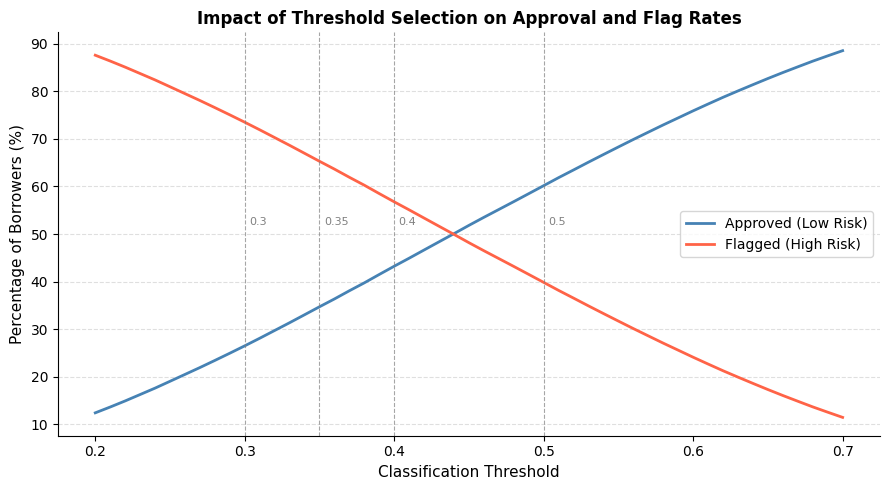

In [31]:
#how threshold choice affects approval and flag rates

fig, ax = plt.subplots(figsize=(9, 5))

thresholds_range = [i/100 for i in range(20, 71)]
flagged_pcts = [(xgb_probs >= t).sum() / len(xgb_probs) * 100 for t in thresholds_range]
approved_pcts = [100 - f for f in flagged_pcts]

ax.plot(thresholds_range, approved_pcts, color='steelblue', linewidth=2, label='Approved (Low Risk)')
ax.plot(thresholds_range, flagged_pcts, color='tomato', linewidth=2, label='Flagged (High Risk)')

for t in [0.30, 0.35, 0.40, 0.50]:
    ax.axvline(x=t, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.text(t + 0.003, 52, f'{t}', fontsize=8, color='gray')

ax.set_xlabel('Classification Threshold', fontsize=11)
ax.set_ylabel('Percentage of Borrowers (%)', fontsize=11)
ax.set_title('Impact of Threshold Selection on Approval and Flag Rates', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

The analysis of threshold sensitivity revealed that at the default classification threshold of 0.5, the model flags 39.8% of applicants as high risk. Lowering the threshold to 0.40 increases the flag rate to 56.8%, and lowering it further to 0.35 flags 65.3% of applicants. The crossover point where approvals and flags are equal falls at approximately 0.42. These figures carry direct business implications. A BNPL lender with thin margins and high exposure to charge-offs may prefer a threshold between 0.35 and 0.40 to catch more potential defaults at the cost of declining more creditworthy applicants. A lender competing aggressively for market share may prefer to operate closer to 0.50 to maximize approval volume. The optimal threshold should be calibrated using the lender's actual cost ratio between a missed default and a missed approval, a calculation that falls outside the scope of this study but that the model's probability outputs are designed to support.